[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Übung / Exercise 3

In [1]:
import numpy as np
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
#from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt


def plot_laplace_plane():
    xa = 20*np.log10(np.abs(x))
    xfta = 20*np.log10(np.abs(xft))
    xa_max = np.max(xa)
    xa_min = np.min(xa)
    print(xa_max, xa_min)

    fig = plt.figure(figsize=(6, 5))
    ax = fig.gca(projection='3d')
    Ncol = 20
    col_tick = np.linspace(-30, 30, Ncol, endpoint=False)
    cmap = mpl.cm.get_cmap('cividis')
    norm = mpl.colors.BoundaryNorm(col_tick, cmap.N)
    surf = ax.plot_surface(sigma, omega, xa,
                           cmap=cmap,
                           norm=norm,
                           rstride=5, cstride=5, linewidth=0, alpha=1)
    ax.plot3D(sigma[:, N//2], omega[:, N//2],
              xfta[:, N//2], 'darkred', lw=3, alpha=1)
    cbar = fig.colorbar(
        surf, ax=ax, ticks=col_tick[::Ncol//10], label=r'|X(s)| in dB')
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_zlim(-30, 30)
    ax.set_xlabel(r'$\Re(s)$')
    ax.set_ylabel(r'$\Im(s)$')
    ax.set_zlabel(r'$|X(s)|$ in dB')
    ax.view_init(azim=-50, elev=45)
    #ax.view_init(azim=-90, elev=90)

In [2]:
N = 2**8
re_s = np.linspace(-10, 10, N)
im_s = np.linspace(-10, 10, N)
sigma, omega = np.meshgrid(re_s, im_s, sparse=False, indexing='xy')
s = sigma+1j*omega

# Laplace plane for $x(t) = \mathrm{e}^{\sigma_0 t} \epsilon(t)$

with $\sigma_0=-10$, region of convergence (ROC): $\Re\{s\}>\sigma_0$

one pole

28.130803608679138 -26.989700043360187


/var/folders/h3/0150r6d162v_492ykc1q11gw0000gn/T/ipykernel_13237/1028442791.py:16: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  ax = fig.gca(projection='3d')


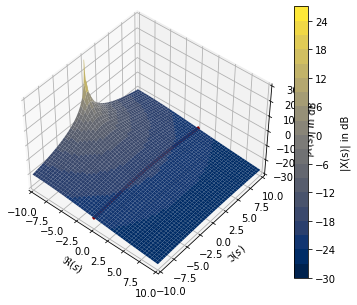

In [3]:
sigma0 = -10
omega0 = 0
s0 = sigma0 + 1j*omega0
x = 1 / (s - s0)
xft = 1 / (1j*omega - s0)
plot_laplace_plane()
plt.savefig('fundamental_signals_laplace_plane_31AEFEF90B_single_pole.pdf')


# Laplace plane for $x(t) = \mathrm{e}^{\sigma_0 t} \cos(\omega_0 t) \epsilon(t)$

with $\sigma_0=-10$ and $\omega_0 = 5$, region of convergence (ROC): $\Re\{s\}>\sigma_0$

two poles, one zero

28.11372220762241 -56.08906945490393


/var/folders/h3/0150r6d162v_492ykc1q11gw0000gn/T/ipykernel_13237/1028442791.py:16: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  ax = fig.gca(projection='3d')


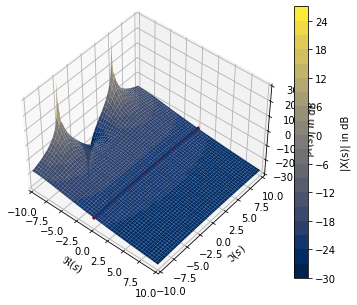

In [4]:
sigma0 = -10
omega0 = +5
x = (s-sigma0) / ((s-sigma0)**2 + omega0**2)
xft = (1j*omega-sigma0) / ((1j*omega-sigma0)**2 + omega0**2)
plot_laplace_plane()
plt.savefig('fundamental_signals_laplace_plane_31AEFEF90B_double_pole_single_zero.pdf')

# Laplace plane for $x(t) = \mathrm{e}^{\sigma_0 t} \cos(\omega_0 t) \epsilon(t)$

with $\sigma_0=0$ and $\omega_0 = 5$, region of convergence (ROC): $\Re\{s\}>\sigma_0$

two poles, one zero

21.12422436801319 -53.07930389121612


/var/folders/h3/0150r6d162v_492ykc1q11gw0000gn/T/ipykernel_13237/1028442791.py:16: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  ax = fig.gca(projection='3d')


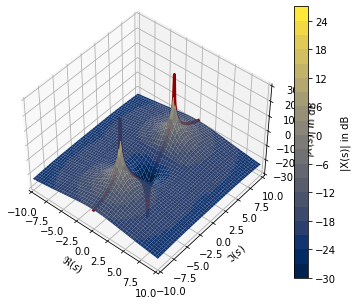

In [5]:
sigma0 = 0
omega0 = +5
x = (s-sigma0) / ((s-sigma0)**2 + omega0**2)
xft = (1j*omega-sigma0) / ((1j*omega-sigma0)**2 + omega0**2)
plot_laplace_plane()
plt.savefig('fundamental_signals_laplace_plane_31AEFEF90B_cos.pdf')

# Laplace plane for $x(t) = \mathrm{e}^{\sigma_0 t} \sin(\omega_0 t) \epsilon(t)$

with $\sigma_0=-10$ and $\omega_0 = 5$, region of convergence (ROC): $\Re\{s\}>\sigma_0$

two poles

28.147851483902752 -40.263289387223494


/var/folders/h3/0150r6d162v_492ykc1q11gw0000gn/T/ipykernel_13237/1028442791.py:16: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  ax = fig.gca(projection='3d')


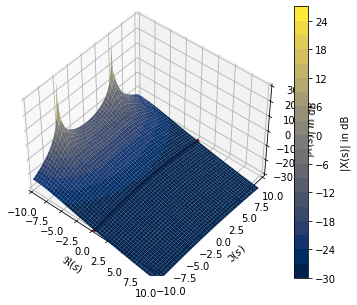

In [6]:
sigma0 = -10
omega0 = 5
x = omega0 / ((s-sigma0)**2 + omega0**2)
xft = (omega0) / ((1j*omega-sigma0)**2 + omega0**2)
plot_laplace_plane()
plt.savefig('fundamental_signals_laplace_plane_31AEFEF90B_double_pole.pdf')

# Laplace plane for $x(t) = \mathrm{e}^{\sigma_0 t} \sin(\omega_0 t) \epsilon(t)$

with $\sigma_0=0$ and $\omega_0 = 5$, region of convergence (ROC): $\Re\{s\}>\sigma_0$

two poles

21.158084389523054 -32.10853365314893


/var/folders/h3/0150r6d162v_492ykc1q11gw0000gn/T/ipykernel_13237/1028442791.py:16: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  ax = fig.gca(projection='3d')


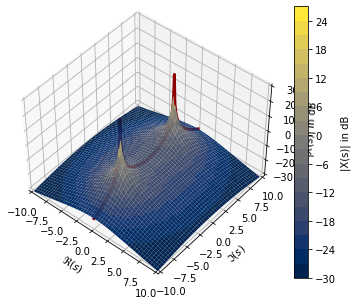

In [7]:
sigma0 = 0
omega0 = 5
x = omega0 / ((s-sigma0)**2 + omega0**2)
xft = (omega0) / ((1j*omega-sigma0)**2 + omega0**2)
plot_laplace_plane()
plt.savefig('fundamental_signals_laplace_plane_31AEFEF90B_sin.pdf')

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.